In [1]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


/tmp/ipykernel_17067/1913841489.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)


In [3]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",")
pd.set_option('display.max_columns', None)


In [4]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [5]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', features)
])


In [6]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor


ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', 'passthrough',
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [7]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [8]:
# ================= #
# 7. MODELO RANDOM FOREST #
# ================= #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=42))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', 'passthrough',
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=10, n_jobs=-1,
                                       random_state=42))])

In [9]:
# ============== #
# 8. EVALUACIÓN  #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)


MAE: 6219.657233571429
RMSE: 8060.50097544405
MAPE: 0.04437059188050844
MAPE(%): 4.437059188050844
R2: 0.9533772913388985


In [10]:
# ======================================== #
# 8.1. DATAFRAME CON RESULTADOS Y ERRORES  #
# ======================================== #

X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df
df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
32025,14,15,2,Business Analyst,High School,Finance,Enterprise,Sweden,Hybrid,134792,146303.0,-11511.0,11511.0
9897,2,14,5,Data Scientist,Master,Healthcare,Medium,USA,No,163189,165511.4,-2322.4,2322.4
16468,18,4,3,Data Scientist,Master,Government,Small,Singapore,Yes,161125,159487.0,1638.0,1638.0
20950,2,14,4,DevOps Engineer,Bachelor,Manufacturing,Enterprise,UK,No,165960,174142.4,-8182.4,8182.4
72250,11,9,1,Machine Learning Engineer,Master,Telecom,Medium,Netherlands,No,154527,160592.4,-6065.4,6065.4
50565,15,12,1,Software Engineer,Bachelor,Consulting,Small,Remote,No,132986,131074.5,1911.5,1911.5
4852,17,1,5,Cloud Engineer,PhD,Education,Startup,USA,Hybrid,201009,202238.7,-1229.7,1229.7
2130,3,14,5,DevOps Engineer,PhD,Technology,Medium,Singapore,Hybrid,142648,145793.5,-3145.5,3145.5
19811,1,3,2,Cybersecurity Analyst,High School,Retail,Startup,UK,Yes,101766,102866.1,-1100.1,1100.1
59212,0,11,4,Data Scientist,High School,Technology,Medium,Australia,No,103226,106368.0,-3142.0,3142.0


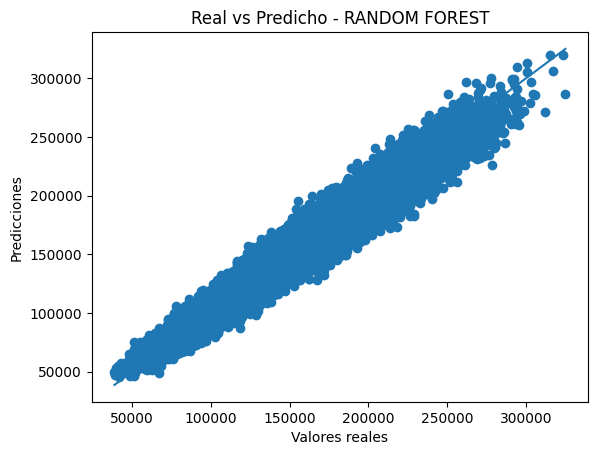

In [11]:
# ====================== #
# 8.2. REAL VS PREDICHO  #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - RANDOM FOREST")
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)
plt.show()


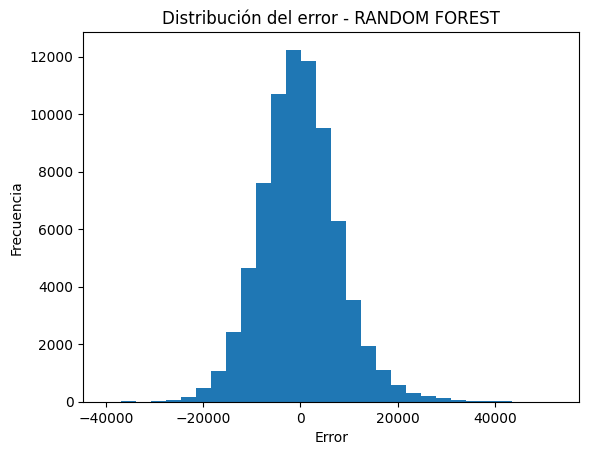

In [12]:
# ============================= #
# 8.3. DISTRIBUCIÓN DE ERRORES  #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error - RANDOM FOREST")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()
